In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
data_path=Path('data/dataset.csv')
df=pd.read_csv(data_path)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [4]:
df.sample(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
10966,10966,5epkVQqWayHxP4ut3zazSw,Ed Solo;Deekline,"Jungle Cakes, Vol. 27",Remember - Original Mix,10,300342,False,0.602,0.985,...,-0.915,1,0.0683,0.0110,0.35500,0.318,0.706,174.976,4,breakbeat
29315,29315,3C5piNghVn2W537rCH1eUj,ILLENIUM;Bahari,To All The Boys: P.S. I Still Love You (Music ...,Crashing (feat. Bahari),37,230000,False,0.585,0.680,...,-6.140,1,0.0448,0.3400,0.00000,0.186,0.250,95.988,4,dubstep
28639,28639,1sTIyJ58UqaMxjGllmkzx2,BaianaSystem,OXEAXEEXU,Tubarão,28,142333,False,0.738,0.925,...,-4.205,1,0.0429,0.0125,0.83600,0.153,0.704,131.065,4,dub
103053,103053,2HXT3Lgmql34XUBVXaJWQ2,Omar Apollo,New RnB,Killing Me,0,165320,True,0.861,0.270,...,-9.515,0,0.0616,0.3010,0.00288,0.124,0.608,84.004,4,soul
104883,104883,1z9c3wLAmRR4eEuae1A7Wh,Rigoberta Bandini,La Emperatriz,La Emperatriz,58,248053,False,0.600,0.462,...,-7.604,1,0.0331,0.5140,0.00691,0.112,0.235,110.996,4,spanish


In [5]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [6]:
df[df.duplicated()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [7]:
df['track_id'].duplicated().sum()

np.int64(24259)

In [8]:
df.shape

(114000, 21)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


In [10]:
df.select_dtypes(include='number')

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,21,384999,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,113996,22,385000,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,113997,22,271466,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,113998,41,283893,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [11]:
df.select_dtypes(include='str')

,track_id,artists,album_name,track_name,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,acoustic
...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,world-music


In [12]:
df['popularity'].value_counts()

popularity
0      16020
22      2354
21      2344
44      2288
1       2140
       ...  
98         7
94         7
95         5
100        2
99         1
Name: count, Length: 101, dtype: int64

In [13]:
df=df.drop(columns='Unnamed: 0')

In [14]:
df.isna().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [15]:
df=df.dropna(subset=['artists','album_name','track_name'])

In [16]:
duplicate_count = df.duplicated(subset=['track_id']).sum()

In [17]:
df_clean = df.drop_duplicates(subset=['track_id'], keep='first')

In [18]:
df_clean.shape

(89740, 20)

In [19]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 89740 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89740 non-null  str    
 1   artists           89740 non-null  str    
 2   album_name        89740 non-null  str    
 3   track_name        89740 non-null  str    
 4   popularity        89740 non-null  int64  
 5   duration_ms       89740 non-null  int64  
 6   explicit          89740 non-null  bool   
 7   danceability      89740 non-null  float64
 8   energy            89740 non-null  float64
 9   key               89740 non-null  int64  
 10  loudness          89740 non-null  float64
 11  mode              89740 non-null  int64  
 12  speechiness       89740 non-null  float64
 13  acousticness      89740 non-null  float64
 14  instrumentalness  89740 non-null  float64
 15  liveness          89740 non-null  float64
 16  valence           89740 non-null  float64
 17  tempo   

In [20]:
df_clean.to_csv("data/dataset_clean.csv", index=False)

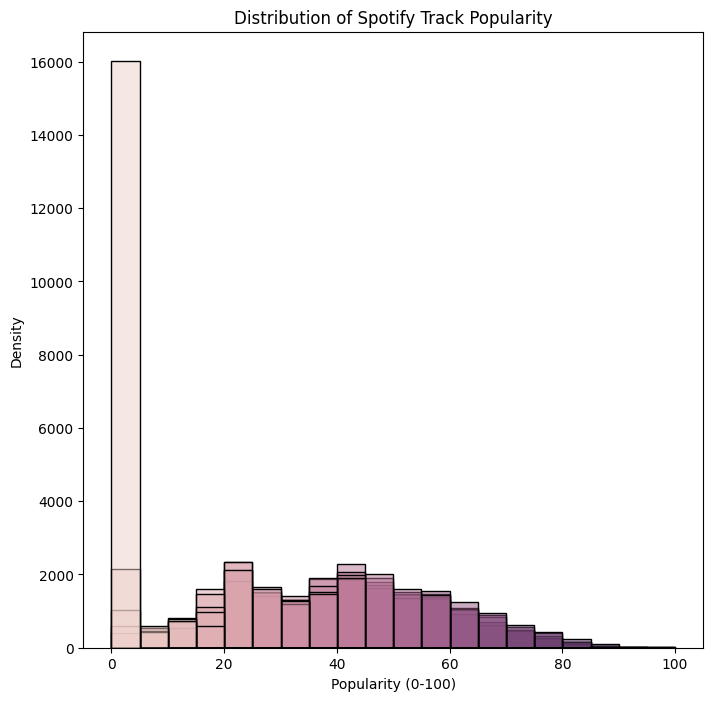

In [21]:
plt.figure(figsize=(8,8))
sns.histplot(data=df,x='popularity',hue='popularity',legend=False,kde=True,bins=20,color='purple')
plt.title('Distribution of Spotify Track Popularity')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Density')
plt.show()

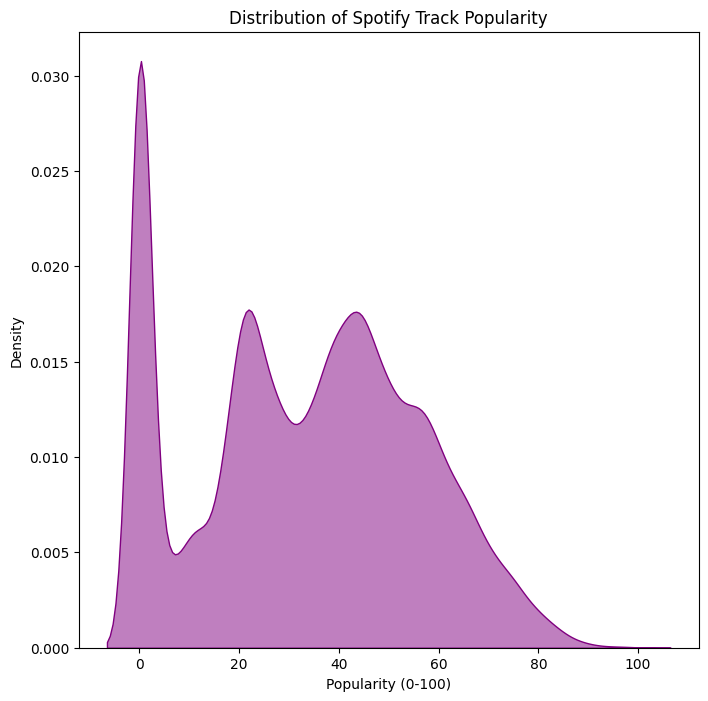

In [22]:
plt.figure(figsize=(8,8))
sns.kdeplot(data=df,x='popularity',fill=True, color='purple', alpha=0.5)
plt.title('Distribution of Spotify Track Popularity')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Density')
plt.show()

In [23]:
print(df['explicit'].unique())
print(df['explicit'].value_counts())

[False  True]
explicit
False    104252
True       9747
Name: count, dtype: int64


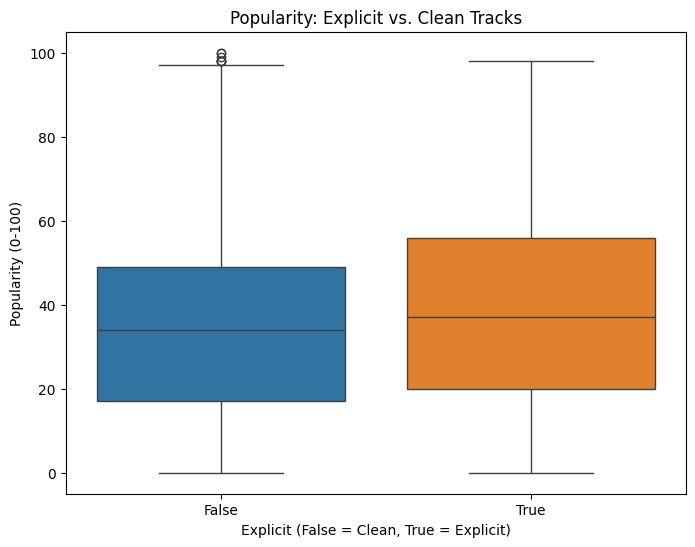

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df,x='explicit',y='popularity',hue='explicit',legend=False)
plt.title('Popularity: Explicit vs. Clean Tracks')
plt.xlabel('Explicit (False = Clean, True = Explicit)')
plt.ylabel('Popularity (0-100)')
plt.show()